# Module 1. Planets, Stars, & the Galaxy 

In this module, we'll explore how galactic dynamics affect planet formation by using exoplanets and their host stars to understand our galactic environment. 

## Learning goals: 
- Use real data from the Transiting Exoplanet Survey Satellite (TESS) to connect the observables of an exoplanet's lightcurve to physical quantites of the system. 
- Use the APOGEE allStar catalog to explore how stars bias our observations of exoplanet transits and influence planet formation.
- Identify trends in the locations, metallicities, radial velocities, radii, and orbital distances of stars and planets in the Milky Way. 
- Relate these trends to planet formation.

If you are unfamiliar with exoplanets, please visit Module 0. to complete a conceptual exploration of exoplanetary systems and their observables. 

We'll begin by installing our dependencies and the APOGEE allStar catalog, if you have not already visited Module 0. and done so. 

In [1]:
import setup as s
from setup import * 
file_path = './tess_data/'

Installing dependencies...
Processing /home/conda/feedstock_root/build_artifacts/appnope_1733332318622/work (from -r requirements.txt (line 1))
Done!


ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: '/System/Volumes/Data/home/conda/feedstock_root/build_artifacts/appnope_1733332318622/work'



Could not import regions, which is required for some of the functionalities of this module.
APOGEE allStar found!


## Module 1.1: Ex(o)ploring other worlds

### Learning goal 
- Use real data from the Transiting Exoplanet Survey Satellite (TESS) to connect the observables of an exoplanet's lightcurve to physical quantites of the system. 

Launched in 2018 as a successor to the Kepler spacecraft, TESS resides in a high Earth equatorial orbit and surveys neighboring suns by staring at $2300~\text{deg}^2$ of the sky for 27 days at a time. If a planet transit during those 27 days, TESS will observe a dip in its host star's brightness.

<figure>
  <img src="helpful_figures/tess.webp" style="display: block; margin-left: auto; margin-right: auto; width: 50%;">
  <div align="center">
  <p>An artistic rendition of TESS courtesy of <a href="https://science.nasa.gov/mission/tess/"> NASA </a> 
  </p>
  </div>
</figure>

The following steps will guide you through the process of detecting a transit using TESS data. 

### Step 1. Download some data 
I've built a function called tess_data_download that takes in the parameters <code>num_obj</code>, <code>order_random</code>, <code>target_index</code>, and <code>search_radius</code>. If no parameters are inputted, light curves for the exoplanets in <a href = "https://exoplanetarchive.ipac.caltech.edu/cgi-bin/TblView/nph-tblView?app=ExoTbls&config=TD" > NASA's table of transiting exoplanets </a>. 

The parameters are as follows: 
<p style="text-indent: 50px;">
<code>num_obj</code>: Tells the function to only download a certain number of objects. 
<p style="text-indent: 50px;">
<code>order_random</code>: If set to False (default) the objects will be ordered in sequential order from the table. Otherwise, objects will be randomly selected from the table
<p style="text-indent: 50px;">
<code>target_index</code>: Selects the index of a specific object you want from the table
<p style="text-indent: 50px;">
<code>search_radius</code>: Defaults to 0.1 arcseconds and determines the radius a TESS detection must fall from the planet's radius to be considered a valid match
</p>

In [2]:
# to select a target object 
target_obj = "WASP-113 b" # gives a nice lightcurve, but feel free to test some others!
s.tess_data_download(target_name=target_obj)

Target name resolved.
File has already been downloaded


mkdir: tess_data: File exists


You can check out <a href='./transiting_exoplanets.csv' > this file </a> and choose your favorite planet to test some different lightcurves. 

Once the download has finished, we can retrieve all the <b>lightcurve</b> we now have for this object. 

<em> Vocab: A lightcurve plots the flux of an object against time </em>

In [3]:
target_obj = target_obj.replace(" ", "_")
target_file_path = file_path+target_obj
lightcurve_files = s.glob.glob(s.os.path.join(target_file_path, '*'))

We can plot just one of our lightcurves to make sure it looks okay. 

Text(0, 0.5, 'Flux (erg/cm$^2$/s)')

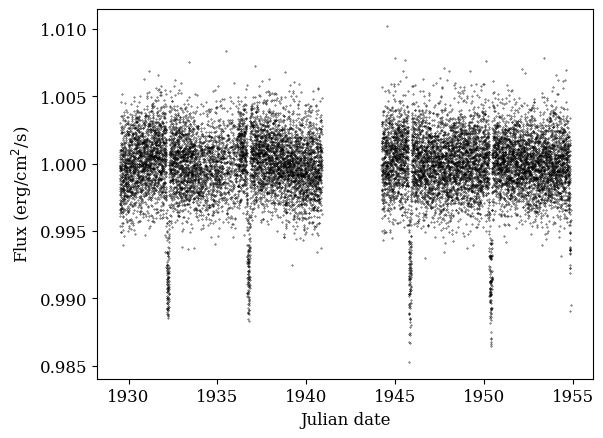

In [4]:
hdu_list = fits.open(lightcurve_files[0], memmap=True)
data = Table(hdu_list[1].data)
# remove data that is flagged as being high quality and data that does not have a value
mask = (data['QUALITY'] == 0) & (~np.isnan(data['PDCSAP_FLUX'])) 
data_filtered = data[mask]
plt.scatter(data['TIME'], data['PDCSAP_FLUX']/np.nanmedian(data['PDCSAP_FLUX']),color = 'k', s= 0.1)
plt.xlabel('Julian date')
plt.ylabel(r'Flux (erg/cm$^2$/s)')

Cool! We can definetly see some variations. But, it's hard to tell which variations are due to the exoplanet and which are due to the motion of the target star relative to us (see Interactive Problem #1 for an example). To highlight the periodic motion we see here and deconvolve any periodicity from the star's motion from the periodicity of an exoplanet's orbit, we can transition this data into frequency-space. However, you'll notice that applying the familiar Fourier transform won't work here. This is because transits do not exhibit sinusoidal shapes, making Fourier transforms an ineffectual method of detecting them. To get around this, we can use the Box Least Squares (BLS) method, which is conceptually similar to a Fourier transform, but models the transit as a "downward box" rather than a sine wave. 

We'll use <code> astropy</code>'s <code>BoxLeastSquares</code> function. You can read more about BLS and its <code>astropy</code> implementation<a href="https://docs.astropy.org/en/stable/timeseries/bls.html" > here</a>.

But, do this, we'll want multiple transits which we can't detect in a single observation unless the orbital period of the planet is less than 13.5 Earth days (TESS typically observes a given star for 27 days). 

Good thing we have multiple observations! Let's merge all of our times, fluxes, and flux errors for each observation into a single list. 

In [5]:
time = []
flux = []
fluxerr = []
for file in lightcurve_files: 
    hdu_list = fits.open(file, memmap=True)
    data = Table(hdu_list[1].data)
    
    #repeat our filtering process 
    mask = (data['QUALITY'] == 0) & (~np.isnan(data['PDCSAP_FLUX']))
    data_filtered = data[mask]
    time = list(data['TIME'])
    flux = list(data['PDCSAP_FLUX'])
    flux_normalized = flux/np.nanmedian(flux)
    fluxerr = list(data['PDCSAP_FLUX_ERR'])
    fluxerr_normalized = fluxerr/np.nanmedian(fluxerr)
    time.extend(time)
    flux.extend(flux_normalized)
    fluxerr.extend(fluxerr_normalized)
# remove any nan values just to be safe
m = np.isnan(flux) | np.isnan(fluxerr)
flux = np.array(flux)[~m]
fluxerr=np.array(fluxerr)[~m]
time = np.array(time)[~m]

Now that we've merged our data, let's apply <code> astropy</code>'s <code>BoxLeastSquares</code> function. As we do this, we'll construct something called a "periodogram" which identifies the underlying frequencies of a signal.

### Step 3. Construct a periodogram

In [6]:
# may take a minute to run depending on how messy the data you selected is. 
model = BoxLeastSquares(np.array(time) * u.day, np.array(flux), dy= np.array(fluxerr))
durations = np.linspace(0.1, 0.2, 20) * u.day # you'll want to change this to narrow in on the period of your target planet
results = model.autopower(durations, frequency_factor=5.0)

We can plot our periodogram by doing the following. I've added a bit to the code that will highlight the transit period that algorithm selects and the harmonics.

T = 4.54 days 


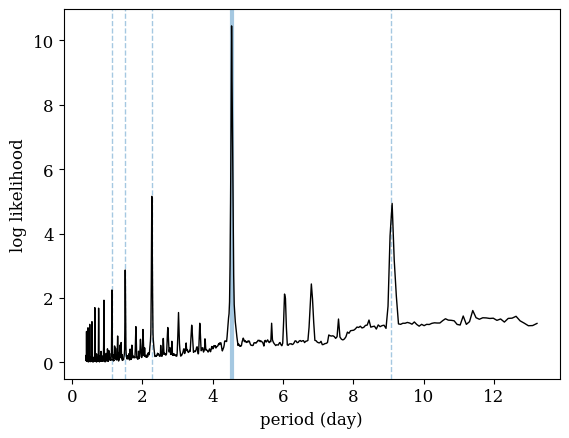

In [7]:
transitperiod = results.period[np.argmax(results.power)]
plt.axvline(transitperiod.value, alpha=0.4, lw=3)
for n in range(2, 5):
    pos_harmonic = n*transitperiod.value
    neg_harmonic= transitperiod.value / n
    if(pos_harmonic <= np.max((results.period).value)): 
        plt.axvline(n*transitperiod.value, alpha=0.4, lw=1, linestyle="dashed")
    if(neg_harmonic >= np.min((results.period).value)):
        plt.axvline(transitperiod.value / n, alpha=0.4, lw=1, linestyle="dashed")
plt.plot(results.period, results.power, color = 'k')
plt.xlabel("period (day)")
plt.ylabel("log likelihood")
print(f"T = {transitperiod.value:.2f} days ")

<b>Search up the orbital period of the exoplanet you selected. Is the output of the code consistent with what you find? How does changing the input parameters of the model affect your result? </b>

<b> Answer:</b> <span style="color:red" > You should see that if the orbital period of your exoplanet does not fall within the range you
provided for <code>duration</code>, the code either will not converge or will converge around the wrong peak. For the example source WASP-90b, you should resolve a period of 3.91 days. </span>. 

Alongside obtaining our period, we can also obtain the depth of our transit, when in the orbital period the transit occurs, how long the transit takes, etc. 

In [8]:
transitperiod = results.period[np.argmax(results.power)].value
transitdepth = results.depth[np.argmax(results.power)]
transittime = results.transit_time[np.argmax(results.power)].value
transitduration = results.duration[np.argmax(results.power)].value

<b> Repeat the steps above on any number of exoplanets (use the download function to get more!). Be sure to save the statistics listed above for each planet. </b>

In [9]:
pl_name = []
pl_ra = []
pl_dec = []
period_ls = []
depth_ls = []
trtime_ls = []
duration_ls=[]

## YOUR IMPLEMENTATION HERE

pl_name.append("WASP-113 b")
hdu_list = fits.open(lightcurve_files[0], memmap=True)
pl_ra.append(hdu_list[0].header['RA_OBJ'])
pl_dec.append(hdu_list[0].header['DEC_OBJ'])
period_ls.append(transitperiod)
depth_ls.append(transitdepth)
trtime_ls.append(transittime)
duration_ls.append(transitduration)

In [10]:
# run the following code once you've retrieved statistics for all planets of interest 

exoplanet_tbl = Table([pl_name, pl_ra, pl_dec, period_ls, depth_ls, trtime_ls, duration_ls], names = ("name", "ra", "dec", "period", "depth", "time", "duration"))

<span style="color:red"> No solutions given here as it is just repeating the same steps as above but for a different planet. However, some common issues you may run into are: 
- Your code converges but you retrieve the wrong period --> Try changing your input parameters. If this doesn't work, its possible the data is too messy for our simple algorithm 
- Your code won't converge to a period --> Unfortunately, our algorithm is probably too simplistic. You may want to choose a different planet. 

Pro-tip for choosing a target planet: The larger the planet, the easier it will be to detect! See Module 0. to learn more. </span> 

## Module 1.2: Meeting the host

### Learning goal 
- Use the APOGEE allStar catalog to explore how stars bias our observations of exoplanet transits and influence planet formation.

### Step 1. Read in APOGEE 

In [11]:
# read in APOGEE, this will take a minute 
apogee_allstar = s.fitsio.read('allStar-dr17-synspec_rev1.fits', ext = 1)
# ignore all APOGEE stars that lack RA and/or DEC values 
m = np.isnan(apogee_allstar['RA']) | np.isnan(apogee_allstar['DEC'])
apogee_allstar = apogee_allstar[~m]

### Step 2. Find your TESS target(s) in APOGEE

In [12]:
# search for an apogee match 
apogee_coords = SkyCoord(ra = apogee_allstar['RA']*u.degree, dec = apogee_allstar['DEC']*u.degree, frame = 'icrs')
planet_coords = SkyCoord(ra=exoplanet_tbl['ra']*u.degree, dec = exoplanet_tbl['dec']*u.degree, frame = 'icrs')
idx, d2d, d3d = planet_coords.match_to_catalog_sky(apogee_coords)
m_t_idx = d2d.arcsec < 1 # we'll want to exclude objects that fall further than 1'' from an apogee source 
exoplanet_tbl['apogee idx'] = idx
exoplanet_apogee_tbl = exoplanet_tbl[m_t_idx]

### Step 3. Plot your TESS target(s) on a Hertzsprung Russel (HR) diagram

Now, it takes a lot of work to determine the precise age and type of a star, but, using the APOGEE catalog, we can plot our exoplanet's host star on a Hertzsprung Russell (HR) diagram to get a rough idea of our host star.  
<figure>
  <img src="helpful_figures/HRDiagram.png" style="display: block; margin-left: auto; margin-right: auto; width: 50%;">
  <div align="center">
  <figcaption>An example HR digram from the Hipparcos catalog and Gliese catalog of nearby stars by <a href="https://en.wikipedia.org/wiki/Hertzsprung%E2%80%93Russell_diagram#/media/File:HRDiagram.png" > Richard Powell </a> 
  </figcaption>
  </div>
</figure>


First, we need to account for how being farther away affects a star's brightness. We can do this using the "distance modulus" $\mu$, which is equal to the apparent magnitude (e.g., the magnitude we see without correcting for distance) minus the absolute magnitude (the distance corrected magnitude). $\mu$ is ALSO equal to $5\log_{10}(d) -5$, a definition that comes from the conventional magnitude scale. We can solve for $M$: 
$$\mu = m - M = 5\log_{10}(d)-5$$
$$M = m - 5\log_{10}(d)-5 $$

Write the following function to find the absolute magntiude given the apparent magnitude and distance: 

In [13]:
def apparent_to_absolute(m,d): 
    M = m - 5 *np.log10(d)-5 
    return M

Now, let's select <em>only</em> nearby stars so that we don't have to worry about how the dust in the interstellar medium influences our observations. An object that is farther away will also be more heavily influenced by dust. So, by selecting only objects particularly close to us $d < 5$, we can get a pretty good approximation of the HR diagram. If we were doing anything more than an approximation of very local stars, we wouldn't be able to ignore dust like this. But, luckily, TESS targets tend to be local, so its a fair approximation to only look at our solar neighborhood.

We obtain distance from parallax: $$d=\frac{1}{p}$$
Here, distance is given in parasecs and parallax is given in arcseconds.

In [14]:
# if you wish to save computation time, limit your apogee catalog 
apogee_limit = 50000
apogee_limited = apogee_allstar[:apogee_limit]

In [15]:
d = 1/(apogee_limited['GAIAEDR3_PARALLAX']) 

# select only local objects and objects that actually have distance values 
m= (d < 5) & (~np.isnan(d))
d = d[m]

# retrieve the magnitudes in the B, R, and G bands 
Bv = apparent_to_absolute(apogee_limited['GAIAEDR3_PHOT_BP_MEAN_MAG'][m], d)
Rv = apparent_to_absolute(apogee_limited['GAIAEDR3_PHOT_RP_MEAN_MAG'][m],d)
Gv = apparent_to_absolute(apogee_limited['GAIAEDR3_PHOT_G_MEAN_MAG'][m],d)

# get the color by subtracting B and R 
color = Bv-Rv 

In [16]:
# repeat this process for our exoplanet's host star
d_target = 1/(apogee_allstar['GAIAEDR3_PARALLAX'][exoplanet_apogee_tbl['apogee idx']]) 
Bv_target = apparent_to_absolute(apogee_allstar['GAIAEDR3_PHOT_BP_MEAN_MAG'][exoplanet_apogee_tbl['apogee idx']], d_target)
Rv_target = apparent_to_absolute(apogee_allstar['GAIAEDR3_PHOT_RP_MEAN_MAG'][exoplanet_apogee_tbl['apogee idx']],d_target)
Gv_target = apparent_to_absolute(apogee_allstar['GAIAEDR3_PHOT_G_MEAN_MAG'][exoplanet_apogee_tbl['apogee idx']],d_target)
color_target = Bv_target-Rv_target 

The APOGEE catalog also contains <code>TEFF</code>, which is the effective temperature of each star. We can overplot that quantity as a color since we know stellar temperature varies as stars evolve. 

In [17]:
temp = apogee_limited['TEFF'][m]

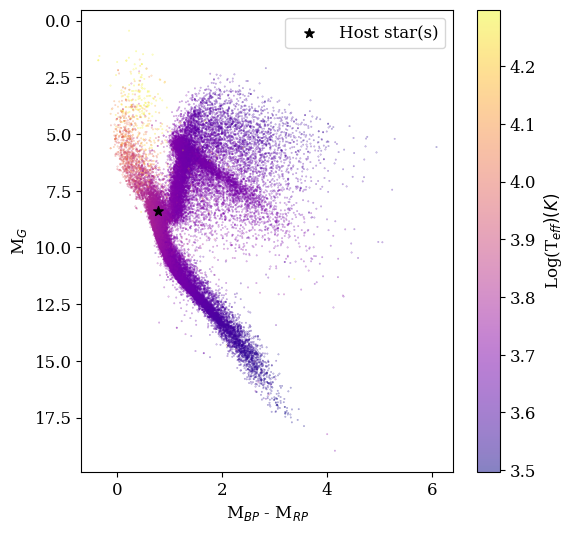

In [18]:
fig, ax = plt.subplots(1,1,figsize = (6,6))
img = ax.scatter(color, Gv, c = np.log10(temp), cmap = 'plasma', s= 0.1, alpha = 0.5)
ax.scatter(color_target, Gv_target, color = 'k', s=50, marker = '*', label = "Host star(s)", zorder =5)
ax.invert_yaxis() 
ax.set_xlabel(r"M$_{BP}$ - M$_{RP}$")
ax.set_ylabel(r"M$_{G}$")
plt.colorbar(img, label = r"Log(T$_{eff}) (K)$")
plt.legend(loc="upper right")

<b> Think about where the sun would fall on this plot. Does this make sense? Why or why not? If not, what's wrong with the plot? </b>


<b> Answer:</b> <span style="color:red"> The sun should fall around M = 5, however, because we have not done any dust correction, we
can expect the CMD to be dimmer (lower magnitudes) and redder. So, it is reasonable for the sun
to fall a little higher and more rightward on the plot that one might expect.</span>

<b> What stellar type does your host star(s) appear to correlate with? Does this make sense? Search up your star's spectral type. Were you correct? </b>

<b>Answer:</b> <span style="color:red"> You’ll have to search this up and check! However, a few mental checks you could run to see if
your results are reasonable...
1. Finding an exoplanet around a red giant or white dwarf star would be rare as it would imply
that these planets survived the star’s expansion phase, which is possible, but tricky.
2. Finding a planet around an older star is often easier as the star is smaller and the planet can cause a greater dip in flux.

If you're using WASP-113 b as your star, you should see that it orbits a G-type star (like us!)</span>

Now, let's get a broader overview of how the exoplanet population looks on this plot. To avoid working through the reduction process hundreds of times, we can cheat a little and just use the data from the <code>transiting_exoplanets.csv</code> file. 

In [19]:
transiting_exo=ascii.read('transiting_exoplanets.csv')

We'll repeat the matching process with APOGEE:

In [20]:
# search for an apogee match 
apogee_coords = SkyCoord(ra = apogee_allstar['RA']*u.degree, dec = apogee_allstar['DEC']*u.degree, frame = 'icrs')
planet_coords = SkyCoord(ra=transiting_exo['ra']*u.degree, dec = transiting_exo['dec']*u.degree, frame = 'icrs')
idx_apogee, d2d, d3d = planet_coords.match_to_catalog_sky(apogee_coords)
m = d2d.arcsec < 1
exoplanet_matches=transiting_exo[m]
apogee_matches = apogee_allstar[idx_apogee[m]]
exoplanet_matches['apogee idx'] = idx_apogee[m]

And repeat the process of obtaining the absolute magnitudes and colors for our matches. 

In [21]:
d_target = 1/(apogee_matches['GAIAEDR3_PARALLAX']) 
Bv_target = apparent_to_absolute(apogee_matches['GAIAEDR3_PHOT_BP_MEAN_MAG'], d_target)
Rv_target = apparent_to_absolute(apogee_matches['GAIAEDR3_PHOT_RP_MEAN_MAG'],d_target)
Gv_target = apparent_to_absolute(apogee_matches['GAIAEDR3_PHOT_G_MEAN_MAG'],d_target)
color_target = Bv_target-Rv_target 

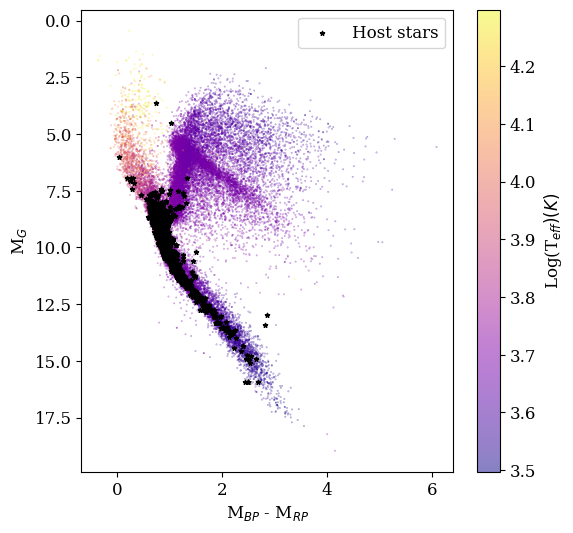

In [22]:
fig, ax = plt.subplots(1,1,figsize = (6,6))
img = ax.scatter(color, Gv, c = np.log10(temp), cmap = 'plasma', s= 0.1, alpha = 0.5)
ax.scatter(color_target, Gv_target, color = 'k', s=10, marker = '*', label = "Host stars")
ax.invert_yaxis() 
ax.set_xlabel(r"M$_{BP}$ - M$_{RP}$")
ax.set_ylabel(r"M$_{G}$")
plt.colorbar(img, label = r"Log(T$_{eff}) (K)$")
plt.legend(loc="upper right")

Interesting! You should see that most exoplanets tend to lie along the main sequence. This makes sense as that's where stars spend the majority of their lifetimes and their violent evolution often leads to planetary destruction.

But, let's relate a star's position on the main sequence to some known quantities of exoplanets. 

If you look at the <code>transiting_exoplanets.csv</code> file, you'll see a few key quantities. Namely, <code>pl_orbper</code>, <code>pl_trandep</code>, and <code>pl_trandur</code>.

These are three of the quantities we calculated at the end of Section 2!

In module 0., we saw that $$ R_{planet} = \sqrt{\frac{D R_{star}^2}{1+D}}$$ and $$ t= \frac{\pi R_{orb}}{TR_{star}}$$ where $D$ is the transit depth, $t$ is the transit duration, and $T$ is the orbital period. 

<b> Complete the following functions to compute the orbital radius and planetary radius of your population of exoplanets.

In [23]:
def compute_orbitalradius(t, P, Rstar): 
    r = (2*t*P*Rstar)/(2*np.pi)
    return r 
def compute_plradius(D, Rstar): 
    R = Rstar*np.sqrt(D/(1+D))
    return R

In [24]:
rm = exoplanet_matches['st_rad'] != 0 # removing objects that have unknown stellar radii
pl_orbrad = compute_orbitalradius(exoplanet_matches['pl_trandur'][rm], exoplanet_matches['pl_orbper'][rm], exoplanet_matches['st_rad'][rm])
pl_rad = compute_plradius(exoplanet_matches['pl_trandep'][rm], exoplanet_matches['st_rad'][rm])

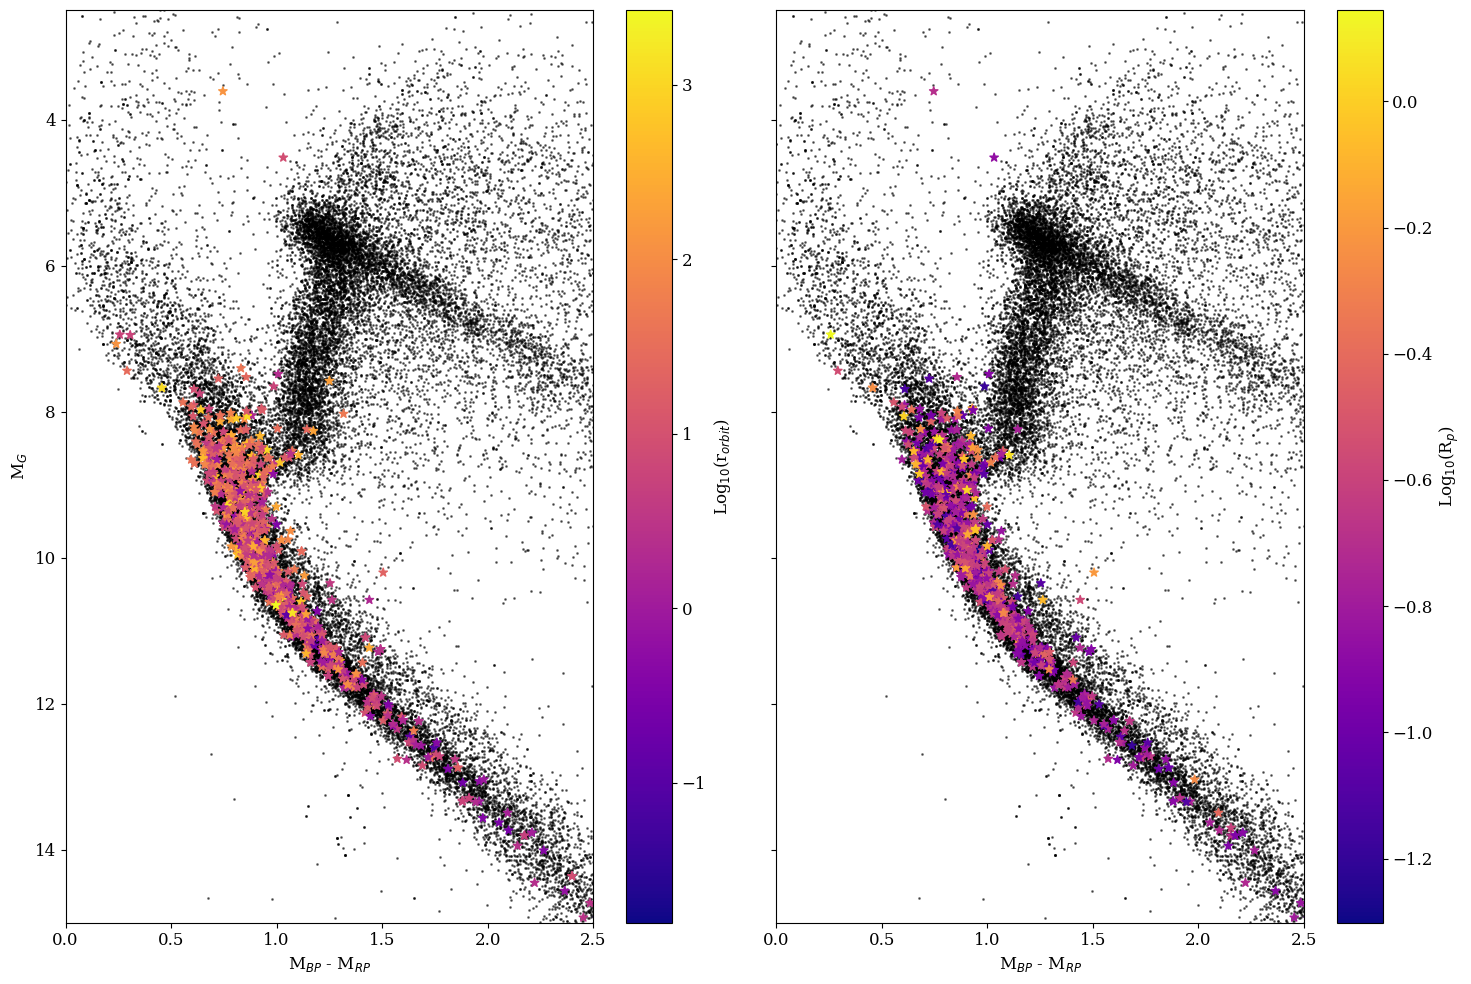

In [25]:
fig, ax = plt.subplots(1,2,figsize = (15,10), sharey=True)
ax[0].scatter(color, Gv, color = 'k', s= 1, alpha = 0.5)
ax[1].scatter(color, Gv, color = 'k', s= 1, alpha = 0.5)
img1 = ax[0].scatter(color_target[rm], Gv_target[rm], c = np.log10(pl_orbrad),  cmap = 'plasma', s=40, marker = '*')
img2= ax[1].scatter(color_target[rm], Gv_target[rm], c = np.log10(pl_rad), cmap = 'plasma', s=40, marker = '*')
ax[0].set_ylim(15, 2.5)
ax[0].set_xlim(0, 2.5)
ax[1].set_xlim(0, 2.5)
ax[0].set_xlabel(r"M$_{BP}$ - M$_{RP}$")
ax[1].set_xlabel(r"M$_{BP}$ - M$_{RP}$")
ax[0].set_ylabel(r"M$_{G}$")
plt.colorbar(img1, label = r"Log$_{10}$(r$_{orbit}$)", ax = ax[0])
plt.colorbar(img2, label = r"Log$_{10}$(R$_{p}$)", ax=ax[1])
plt.tight_layout()

Notice how planets tend to exhibit larger orbital radii for brighter stars. This is likely a result of the fact that younger stars tend to be brighter, younger, and more variable, meaning a planet that is too close, simply would not survive the violent star. Additionally, note the small scattering of points that fall closest to the red giant branch--they all exhibit larger orbital radii. Again, this is likely because stars expand as they begin their evolution into red giants, meaning that planets too close to their host star will be enveloped. 

Similarly, we see that planets with larger radii tend to occur more around brighter stars (if you don't see it, look for the smattering of yellow points on the right figure). However, unlike the orbital radius case, this is a selection effect! Larger planets are easier to detect and its more difficult to detect exoplanets, in general, around brighter stars. Therefore, we are more likely to see a bias toward planets with larger radii around younger stars. 

## Module 1.3: The big picture

### Learning goal 
- Identify trends in the locations, metallicities, radial velocities, radii, and orbital distances of stars and planets in the Milky Way 
- Relate these trends to planet formation

Now that we've seen how stellar hosts influence their exoplanets, let's explore the role of the greater galactic environment. We can understand our galaxy through the following image: 
<figure>
  <img src="helpful_figures/galactic_anatomy.webp" style="display: block; margin-left: auto; margin-right: auto; width: 50%;">
  <div align="center">
  <p>The anatomy of the Milky Way, courtesy of Kaley Brauer, MIT.</a> 
  </p>
  </div>
</figure>

Currently, many Galactic astronomers are puzzling over the Milky Way's formation. Many speculate that the thin disk was formed more recently as a result of recent gas accretion processes while the thick disk formed earlier, during a rapid and turbulent phase. We expect stars that formed in the early universe (e.g., the thick) to be less metal rich because they would have formed before Type Ia supernovae could enrich the Universe with iron and other metals. Therefore, we expect the thin disk to be metal rich and the thick disk to be metal poor. Since the exoplanets we're looking at fall in our solar neigborhood (< 5 pc), let's explore the distribution of stellar metallicities in this region. Ideally, we should see a lot of higher-metallicity stars as we fall in the thin disk of the galaxy.

In [26]:
# first, we'll select our solar neighborhood (d < 5 pc)
p = apogee_limited['GAIAEDR3_PARALLAX']
d = 1/p
m = (d < 5) & (~np.isnan(p)) & (p> 0)
neighbor_distance = d[m]
neighbors = apogee_limited[m]

Metallicity can be defined as the ratio of iron to hydrogen ([Fe/H]). However, we don't just want to know if a star is metal rich, we want to know if it contains more metal than it <em> should </em>. So, we'll need to also look at the ratio of an alpha process element (Magnesium, for example) over iron. By investigating the ratio of [Fe/H] to [Mg/Fe], we will be able to quantify if the star is more metal rich than we would otherwise expect based on its [Mg/Fe] ratio. 

Based on the image above, we should expect our local neighborhood to exhibit a higher [Fe/H] ratio than objects that fall outside thet thin disk. We can look at objects in the thick disk by investigating stars at disk height $|z| > $ 5 pc 

In [27]:
# let's find some objects that fulfill this criteria 
m = np.abs(d) > 5 

not_neighbors = apogee_limited[m]
not_neighbors_distance = d[m]

# convert to galactic coordinates 
coords = SkyCoord(ra = not_neighbors['RA']*u.degree, dec = not_neighbors['DEC']*u.degree, frame = 'icrs')
l = (coords.galactic).l
b = (coords.galactic).b

# retrieve z 
z = not_neighbors_distance*np.sin(l) 


Text(0, 0.5, '[Mg/Fe]')

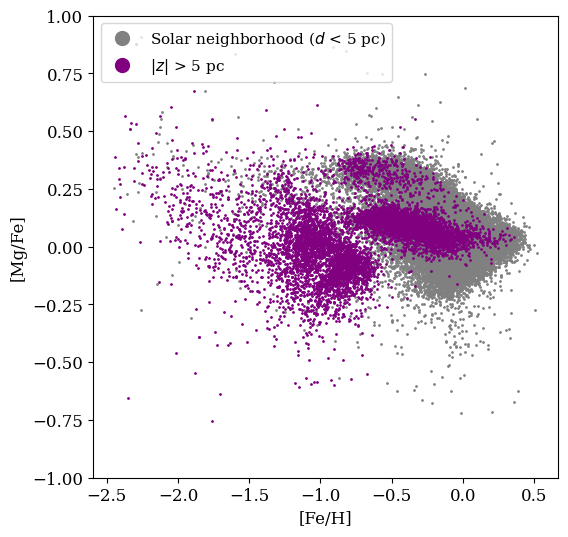

In [28]:
from matplotlib.lines import Line2D
# make a plot! 

fig, ax = plt.subplots(1,1,figsize = (6,6))
ax.scatter(neighbors['FE_H'], neighbors['MG_FE'], s= 1, label = r'Solar neighborhood ($d$ < 5 pc)', color = 'grey')
ax.scatter(not_neighbors['FE_H'], not_neighbors['MG_FE'], s=1, label = r'$|z|$ > 5 pc', color = 'purple')
ax.set_ylim(-1,1)
legend_elements = [Line2D([0], [0], marker='o', color='w', label=r'Solar neighborhood ($d$ < 5 pc)',
                          markerfacecolor='grey', markersize=12), 
                          Line2D([0], [0], marker='o', color='w', label=r'$|z|$ > 5 pc',
                          markerfacecolor='purple', markersize=12)]
plt.legend(handles =legend_elements, loc = 'upper left', fontsize = 11)
ax.set_xlabel('[Fe/H]')
ax.set_ylabel('[Mg/Fe]')

We can see that our neighborhood is more metal-rich than the high altitude stars we've selected. However, you should see that we still have lots of alpha rich stars in our neighborhood. Why? 

Here's a hint: galaxies are dynamic! It's possible for mixing between the thin and thick disks to occur. A tracer of this should be the motion of the stars. We should see divide in the radial velocities of stars between metal-rich and alpha-rich stars.

Text(0, 0.5, '[Mg/Fe]')

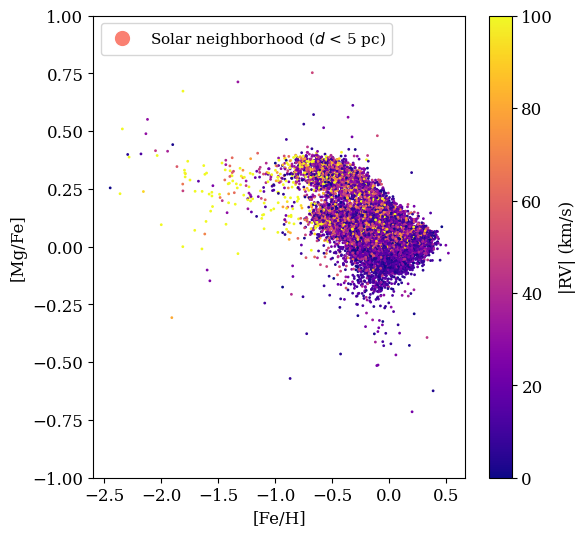

In [29]:
fig, ax = plt.subplots(1,1,figsize = (6,6))
img = ax.scatter(neighbors['FE_H'], neighbors['MG_FE'], s= 1, label = r'Solar neighborhood ($d$ < 5 pc)', c =np.abs(neighbors['GAIAEDR3_DR2_RADIAL_VELOCITY']), cmap = 'plasma', vmin =0, vmax = 100)
plt.colorbar(img, ax = ax, label ="|RV| (km/s)")
ax.set_ylim(-1,1)
plt.legend(handles = [Line2D([0], [0], marker='o', color='w', label=r'Solar neighborhood ($d$ < 5 pc)',
                          markerfacecolor='salmon', markersize=12)], loc = 'upper left', fontsize = 11)
ax.set_xlabel('[Fe/H]')
ax.set_ylabel('[Mg/Fe]')

Note the yellow points that fall that high radial velocities and venture into lower metallicities. These are likely immigrants from the thick disk! 

Let's explore whether these thick disk immigrants are more or less likely to host exoplanets than their stationary thick disk counterparts and their new thin disk neighbors. 

Text(0, 0.5, '[Mg/Fe]')

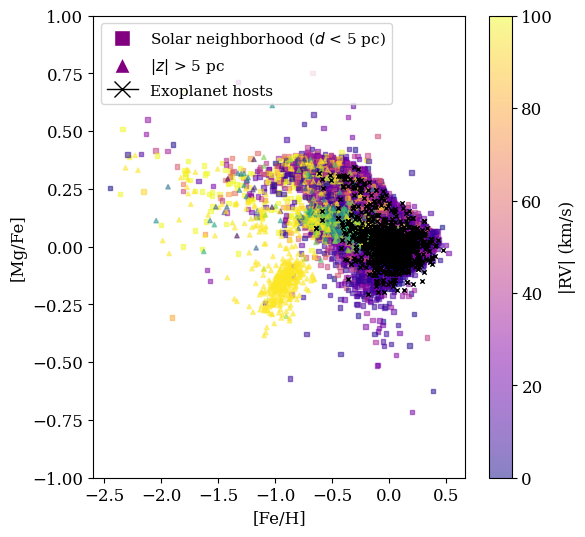

In [30]:
fig, ax = plt.subplots(1,1,figsize = (6,6))
img = ax.scatter(neighbors['FE_H'], neighbors['MG_FE'], s= 10,alpha = 0.5, label = r'Solar neighborhood ($d$ < 5 pc)', c =np.abs(neighbors['GAIAEDR3_DR2_RADIAL_VELOCITY']), marker = 's', cmap = 'plasma', vmin =0, vmax = 100)
ax.scatter(not_neighbors['FE_H'], not_neighbors['MG_FE'], s=10, alpha = 0.5, c =np.abs(not_neighbors['GAIAEDR3_DR2_RADIAL_VELOCITY']), label = r'$|z|$ > 5 pc', marker = '^',  vmin =0, vmax = 100)
ax.scatter(apogee_allstar['FE_H'][exoplanet_matches['apogee idx'][rm]], apogee_allstar['MG_FE'][exoplanet_matches['apogee idx'][rm]], color = 'k', alpha = 1, marker = 'x', s =10, label = "Exoplanet hosts")

plt.colorbar(img, ax = ax, label ="|RV| (km/s)")
ax.set_ylim(-1,1)
plt.legend(handles = [Line2D([0], [0], marker='s', color='w', label=r'Solar neighborhood ($d$ < 5 pc)',
                          markerfacecolor='purple', markersize=12), 
                          Line2D([0], [0], marker='^', color='w', label=r'$|z|$ > 5 pc',
                          markerfacecolor='purple', markersize=12),
                          Line2D([0], [0], marker='x', color='k', label=r'Exoplanet hosts',
                          markerfacecolor='k', markersize=12)], loc = 'upper left', fontsize = 11)
ax.set_xlabel('[Fe/H]')
ax.set_ylabel('[Mg/Fe]')

Our exoplanet sample definetly seems to prefer the thin disk. However, that is also where the majority of our sample falls as many objects in the thick disk fall further away and therefore lack radial velocity measurements. Let's investigate if any of the physical quantities of our exoplanet sample correlate to the planet's status as a thin or thick disk member. 

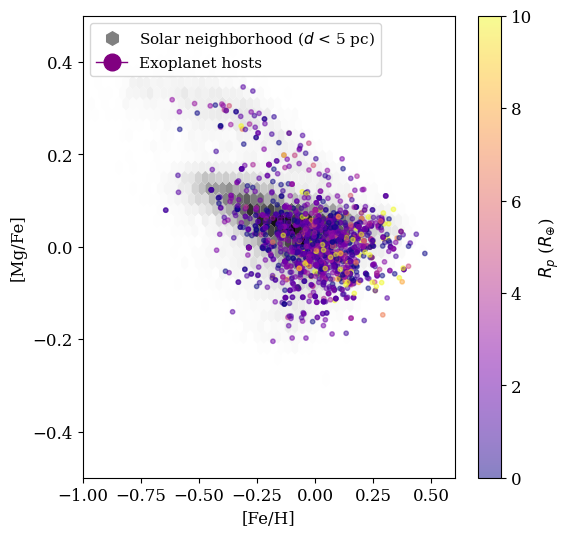

In [31]:
fig, ax = plt.subplots(1,1,figsize = (6,6))
ax.hexbin(neighbors['FE_H'], neighbors['MG_FE'],cmap='Greys', edgecolors="None", mincnt=1)
img = ax.scatter(apogee_allstar['FE_H'][exoplanet_matches['apogee idx'][rm]], apogee_allstar['MG_FE'][exoplanet_matches['apogee idx'][rm]], c=exoplanet_matches['pl_rade'][rm], cmap = 'plasma', alpha = 0.5, marker = 'o', s =10, label = "Exoplanet hosts", vmin = 0, vmax = 10)
plt.colorbar(img, ax = ax, label ="$R_p$ ($R_{\oplus}$)")
ax.set_ylim(-0.5,0.5)
ax.set_xlim(-1, 0.6)
ax.set_xlabel('[Fe/H]')
ax.set_ylabel('[Mg/Fe]')
plt.legend(handles = [Line2D([0], [0], marker='h', color='w', label=r'Solar neighborhood ($d$ < 5 pc)',
                          markerfacecolor='grey', markersize=12), 
                          Line2D([0], [0], marker='o', color='purple', label=r'Exoplanet hosts',
                          markerfacecolor='purple', markersize=12)], loc = 'upper left', fontsize = 11)

Very cool! It looks like planets with larger radii (e.g., our gas giants) are more likely to reside in the thin disk than the thick disk. 

<b> Jot down some thoughts on why this might be the case: </b>

<b> Answer: </b> 

<span style = "color:red"> As a result of both its higher density and anisotropic gas distribution (e.g., the spiral arms of the galaxy), the thin disk is home to more instabilities which lead to gravitational collapse and gas planet formation. </span>

<b> Do our results say anything about the formation conditions of rocky worlds? </b>

<b> Answer: </b> 

<span style= "color:red" > We know they have less preference for the thin disk than gas giants. However, because our sample is biased toward closer sources and therefore is more biased toward the thin disk, we can't say that rocky worlds <em>prefer</em> the thin disk. </span>